In [1]:
import torch
print(f"Is GPU available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Is GPU available? True
GPU Name: Tesla T4


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

LOOK_BACK = 50
EPOCH_LIST = [10, 25, 50]

In [3]:
raw = {}

raw["MSFT"] = yf.download("MSFT", start="2015-01-01", auto_adjust=True, progress=False)
raw["NVDA"] = yf.download("NVDA", start="2015-01-01", auto_adjust=True, progress=False)

# NVDA → returns
raw["NVDA"]["Return"] = raw["NVDA"]["Open"].pct_change()
raw["NVDA"] = raw["NVDA"].dropna()

In [4]:
data = {}

# MSFT → price
msft_prices = raw["MSFT"]["Open"].values.reshape(-1,1)

# NVDA → returns
nvda_returns = raw["NVDA"]["Return"].values.reshape(-1,1)

data["MSFT"] = msft_prices
data["NVDA"] = nvda_returns

In [5]:
splits, scalers = {}, {}

for t in ["MSFT","NVDA"]:
    series = data[t]
    split = int(len(series)*0.8)

    train, test = series[:split], series[split:]

    scaler = MinMaxScaler() if t=="MSFT" else StandardScaler()

    train_sc = scaler.fit_transform(train)
    test_sc  = scaler.transform(test)

    splits[t] = (train_sc, test_sc, split)
    scalers[t] = scaler

In [6]:
def create_sequences(data, lb):
    X,y=[],[]
    for i in range(lb,len(data)):
        X.append(data[i-lb:i,0])
        y.append(data[i,0])
    return np.array(X), np.array(y)

In [7]:
predictions = {}

def build_model():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(LOOK_BACK,1)),
        Dropout(0.2),
        LSTM(64),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

for t in ["MSFT","NVDA"]:
    train_sc, test_sc, split = splits[t]
    scaler = scalers[t]

    ctx = np.concatenate([train_sc[-LOOK_BACK:], test_sc])

    Xtr,ytr = create_sequences(train_sc,LOOK_BACK)
    Xte,yte = create_sequences(ctx,LOOK_BACK)

    Xtr = Xtr.reshape(-1,LOOK_BACK,1)
    Xte = Xte.reshape(-1,LOOK_BACK,1)

    predictions[t] = {}

    for ep in EPOCH_LIST:
        m = build_model()
        m.fit(Xtr,ytr,epochs=ep,batch_size=32,verbose=0)

        pred_sc = m.predict(Xte, verbose=0)

        pred = scaler.inverse_transform(pred_sc)
        real = scaler.inverse_transform(yte.reshape(-1,1))

        predictions[t][ep] = {"real":real, "pred":pred}

        print(f"{t} | {ep} epochs done")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MSFT | 10 epochs done


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MSFT | 25 epochs done


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

NVDA | 10 epochs done


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


NVDA | 25 epochs done


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


NVDA | 50 epochs done


In [8]:
for t in ["MSFT","NVDA"]:
    print(f"\n{t}")
    print(f"{'Ep':<6} {'RMSE':>8} {'MAE':>8} {'R2':>8}")

    for ep in EPOCH_LIST:
        r = predictions[t][ep]["real"].flatten()
        p = predictions[t][ep]["pred"].flatten()

        rmse = np.sqrt(mean_squared_error(r,p))
        mae  = mean_absolute_error(r,p)
        r2   = r2_score(r,p)

        print(f"{ep:<6} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}")


MSFT
Ep         RMSE      MAE       R2
10      15.4243  12.4145   0.8773
25      16.0113  13.4475   0.8678
50       9.2080   7.0897   0.9563

NVDA
Ep         RMSE      MAE       R2
10       0.0320   0.0234   0.0232
25       0.0322   0.0236   0.0088
50       0.0381   0.0270  -0.3863


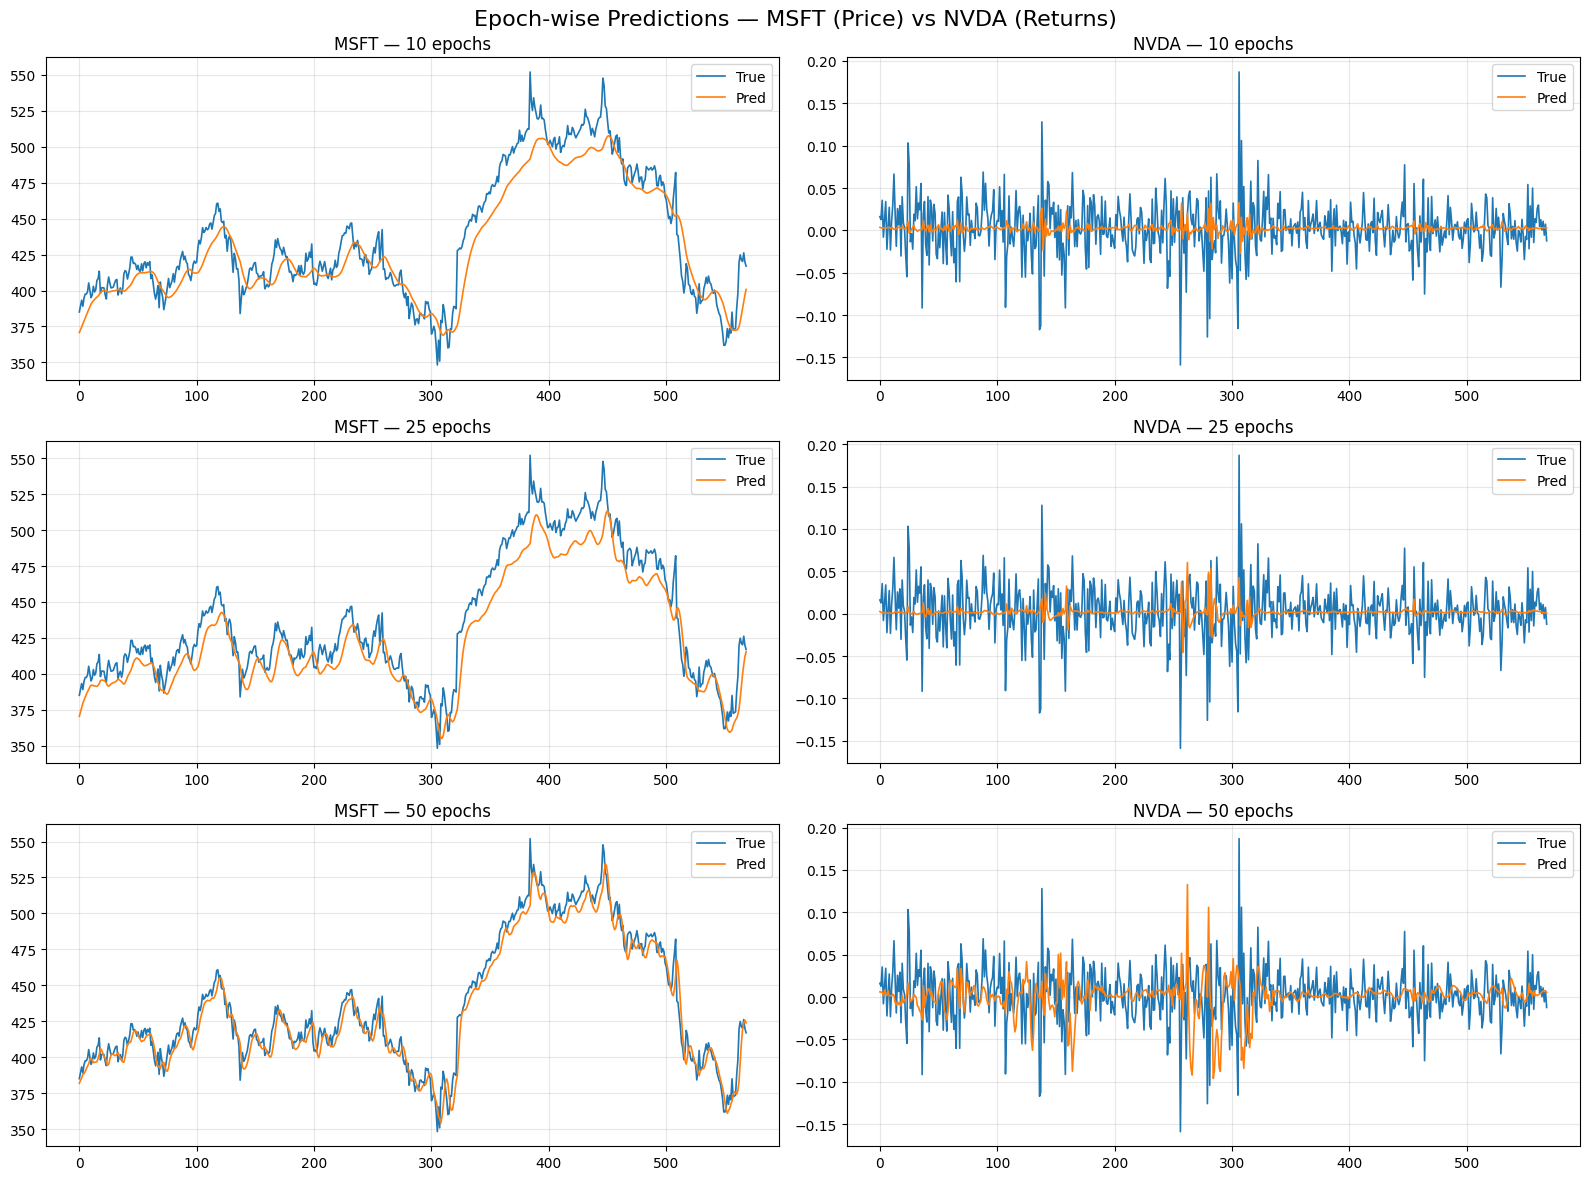

In [9]:
fig, axes = plt.subplots(len(EPOCH_LIST), 2, figsize=(16, 4*len(EPOCH_LIST)))
fig.suptitle("Epoch-wise Predictions — MSFT (Price) vs NVDA (Returns)", fontsize=16)

for i, ep in enumerate(EPOCH_LIST):
    for j, t in enumerate(["MSFT","NVDA"]):
        ax = axes[i, j]

        real = predictions[t][ep]["real"].flatten()
        pred = predictions[t][ep]["pred"].flatten()

        ax.plot(real, label="True", linewidth=1.2)
        ax.plot(pred, label="Pred", linewidth=1.2)

        ax.set_title(f"{t} — {ep} epochs")
        ax.grid(True, alpha=0.3)
        ax.legend()

plt.tight_layout()
plt.show()